#### Augmentation of Downloaded data
##### Preprocessing with ImageDataGenerator:-
###### Apply all the transformations defined in `train_datagen` (rescaling, rotation, zoom, and horizontal flips) in real-time as images are loaded
###### Resize all images to 224×224 pixels
###### Organize them into batches of 32 images

In [1]:
import os
import shutil

In [2]:
# Define source and target folder
source_dir = "C:/Users/acer/Python_Programs/Projects/Steel-surface-defect-detector/data/raw"
target_base = "C:/Users/acer/Python_Programs/Projects/Steel-surface-defect-detector/data/raw"

In [3]:
for filename in os.listdir(source_dir):
    file_path = os.path.join(source_dir, filename) 
    ''' For each item, this creates 
    a complete file path by joining the directory path with the filename.'''
    # Skip directories and hidden files
    if not os.path.isfile(file_path):
        continue

In [4]:
# Loop over files
for filename in os.listdir(source_dir):
    file_path = os.path.join(source_dir, filename)
    if filename.startswith("RS"):
        label = "rolled_in_scale"
    elif filename.startswith("PS"):
        label = "pitted_surface"
    elif filename.startswith("IN"):
        label = "inclusion"
    elif filename.startswith("CR"):
        label = "crazing" 
    elif filename.startswith("PA"):
        label = "patches"
    elif filename.startswith("SC"):
        label = "scratches"
    else:
        continue
    target_path = os.path.join(target_base, label, filename)
    # This line constructs a destination path for the file by joining three components:
    # - `target_base`: The base directory where files will be moved to
    # - `label`: The category folder determined by the file prefix (like "rolled_in_scale", "pitted_surface", etc.)
    # - `filename`: The original filename
    shutil.move(file_path, target_path)
    # This line uses the `shutil.move()` function to move the file from its original location 
    # (`file_path`) to the new categorized location (`target_path`). 
    # This effectively organizes files into subdirectories based on their prefixes.

#### Complete Code Explanation

This code organizes files from a source directory into categorized subdirectories based on filename prefixes:

1. **File Iteration**: Loops through all items in `source_dir` using `os.listdir()`

2. **Categorization Logic**: 
   - Examines each filename's prefix (e.g., "RS", "PS", "IN")
   - Maps prefixes to specific categories (e.g., "RS" → "rolled_in_scale")
   - Skips files with unrecognized prefixes using `continue`

3. **File Movement**:
   - Constructs a destination path combining `target_base`, the determined category label, and the original filename
   - Uses `shutil.move()` to relocate each file to its appropriate category folder

This script essentially implements an automated file sorting system, creating a more organized directory structure based on filename conventions.

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
    #Imports the ImageDataGenerator class from Keras
train_datagen = ImageDataGenerator( #instance of ImageDataGenerator
    rescale=1./255, #Scales pixel values from the default 0-255 range to 0-1 range
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    directory="C:/Users/acer/Python_Programs/Projects/Steel-surface-defect-detector/data/raw",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' # Returns labels in categorical format (one-hot encoded)
) 
'''
1. Read images from the 'raw' directory
2. Apply all the transformations defined in `train_datagen` (rescaling, rotation, zoom, and horizontal flips) in real-time as images are loaded
3. Resize all images to 224×224 pixels
4. Organize them into batches of 32 images
5. Convert class labels to categorical (one-hot encoded) format
'''

Found 1440 images belonging to 6 classes.


"\n1. Read images from the 'raw' directory\n2. Apply all the transformations defined in `train_datagen` (rescaling, rotation, zoom, and horizontal flips) in real-time as images are loaded\n3. Resize all images to 224×224 pixels\n4. Organize them into batches of 32 images\n5. Convert class labels to categorical (one-hot encoded) format\n"

In [7]:
train_generator.class_indices


{'crazing': 0,
 'inclusion': 1,
 'patches': 2,
 'pitted_surface': 3,
 'rolled-in_scale': 4,
 'scratches': 5}

#### Visualization of Augmented batch

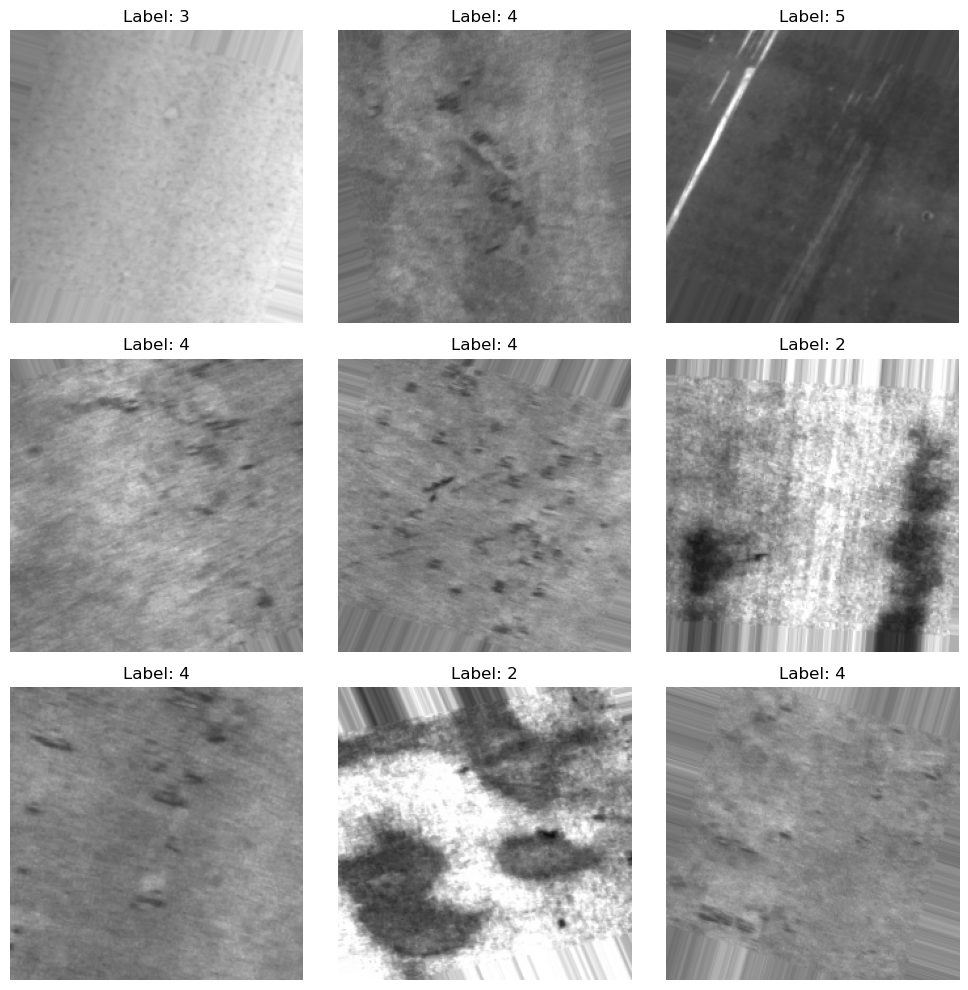

In [19]:
import matplotlib.pyplot as plt

# Fetch one batch
images, labels = next(train_generator)

# Show first 9 images from the batch
plt.figure(figsize=(10, 10)) #Creates a new figure with dimensions of 10x10 inches.
for i in range(9): #iterates through the first 9 images in the batch
    plt.subplot(3, 3, i + 1) #Creates a 3×3 grid of subplots and selects the (i+1)th subplot
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i].argmax()}") 
    ''' labels[i]` accesses the label for the i-th image in the batch. 
    This is likely a vector/array.argmax()` is a NumPy/TensorFlow/PyTorch method that returns the 
    index of the maximum value in the array. For example, if `labels[i]` is `[0, 0, 1, 0, 0]`, then `labels[i].argmax()` 
    returns `2` 
    '''
    plt.axis('off') #Hides the x and y axes
    plt.tight_layout()
    plt.show()


#### Exploratory Data Analysis
- Understand the dataset statistically and visually so you can:
- Detect class imbalance
- Spot issues (e.g. blurry images, duplicates, etc.)
- Build better models later  

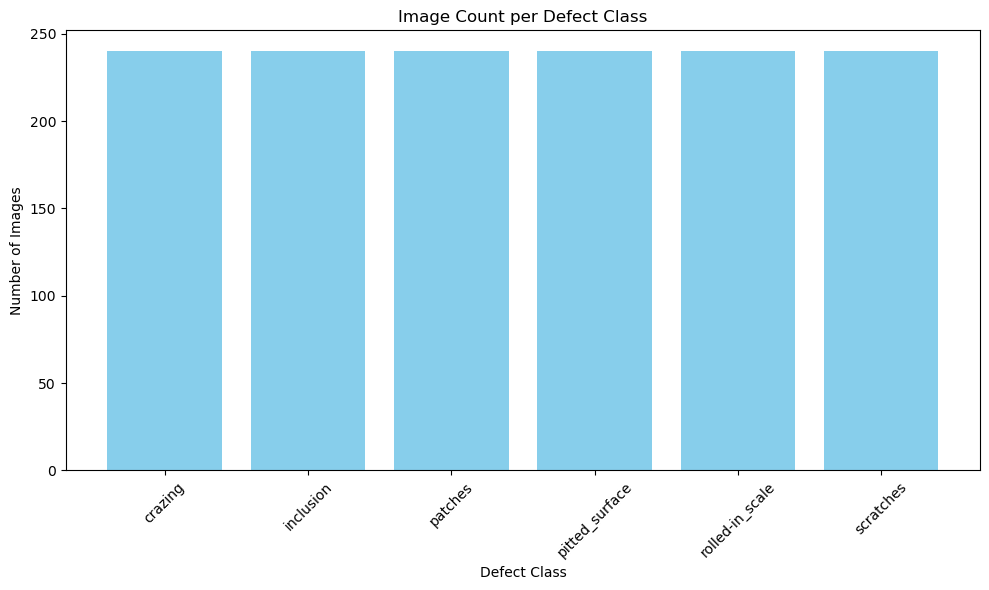

In [52]:
import os
import matplotlib.pyplot as plt

data_path =  "C:/Users/acer/Python_Programs/Projects/Steel-surface-defect-detector/data/raw"
classes = {}

# Loop through each class folder
for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)
    '''
     When we loop through `os.listdir(data_path) we get a list of all items 
     (both files and directories), for each class we repeat the code below,
     first it will run for ex. crazing.
     '''
    if os.path.isdir(class_path): # checks for 
        # Count number of .jpg files
        num_images = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        classes[class_name] = num_images

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(classes.keys(), classes.values(), color='skyblue')
plt.xlabel('Defect Class')
plt.ylabel('Number of Images')
plt.title('Image Count per Defect Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Step-by-Step Explanation
1. os.listdir(class_path)
- Returns a list of all files and directories inside class_path.
- Example output:
['CR_001.jpg', 'CR_002.jpg', 'notes.txt', 'CR_003.jpg', '.DS_Store']

2. [f for f in ... if f.endswith('.jpg')] -
- This is a list comprehension.
- It iterates over every file f in the list, and keeps only those that end with .jpg.
- Filtered result:
  ['CR_001.jpg', 'CR_002.jpg', 'CR_003.jpg']:-
  
3.  len(...)
- Calculates the length of the filtered list, i.e., the number of .jpg files.

In [66]:
classes

{'crazing': 240,
 'inclusion': 240,
 'patches': 240,
 'pitted_surface': 240,
 'rolled-in_scale': 240,
 'scratches': 240}

#### 👀 Visualizing Sample Images Per Class

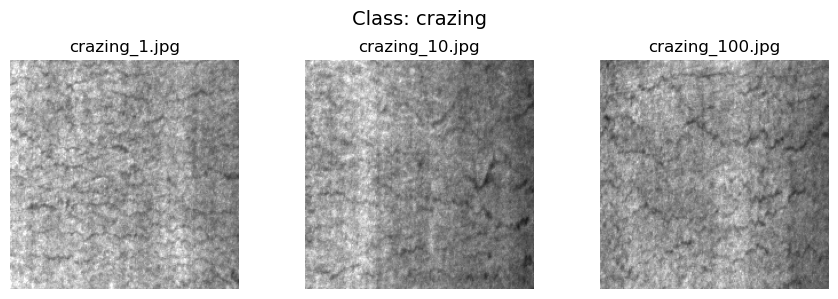

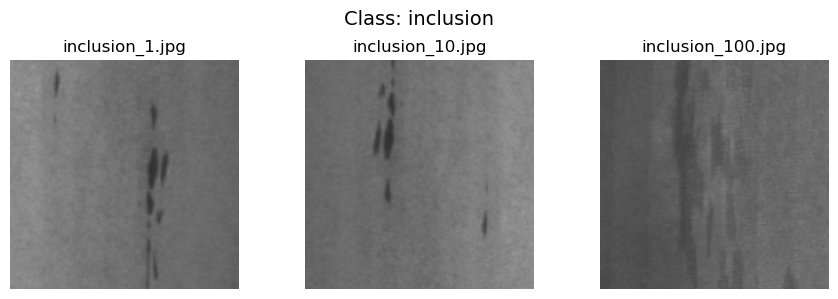

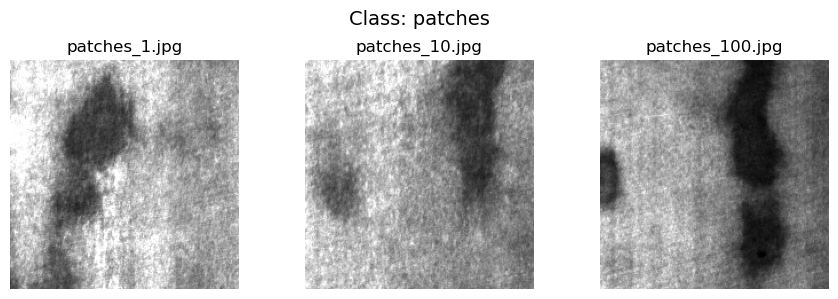

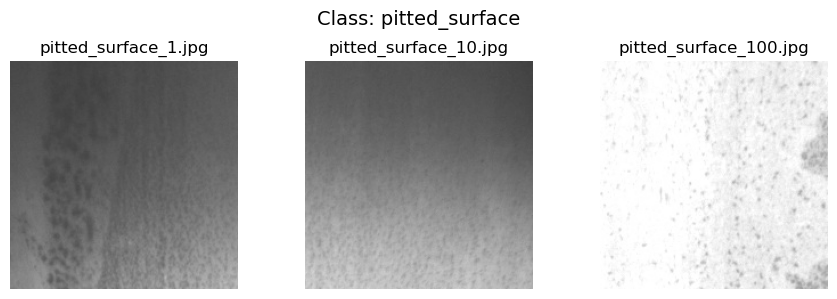

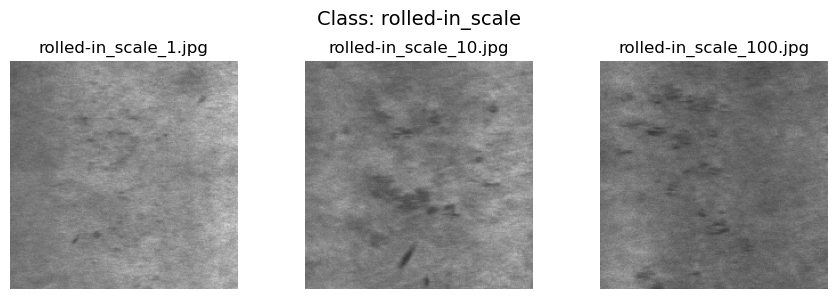

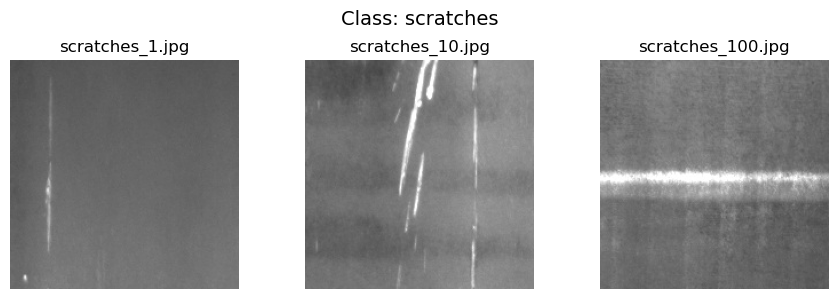

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "data/raw"
class_names = os.listdir(data_path)

# Show 3 images per class
for class_name in class_names:
    class_path = os.path.join(data_path, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')][:3]

    plt.figure(figsize=(9, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=14)

    for i, image_name in enumerate(image_files): #enumerate() function adds a counter to each item in a list or other iterable.Returns (index, filename) for each image in image_files.
        image_path = os.path.join(class_path, image_name)
        img = mpimg.imread(image_path)

        plt.subplot(1, 3, i + 1) #Creates a subplot grid of 1 row, 3 columns, and selects the i+1-th position.
        plt.imshow(img, cmap='gray')
        plt.title(f"{image_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
